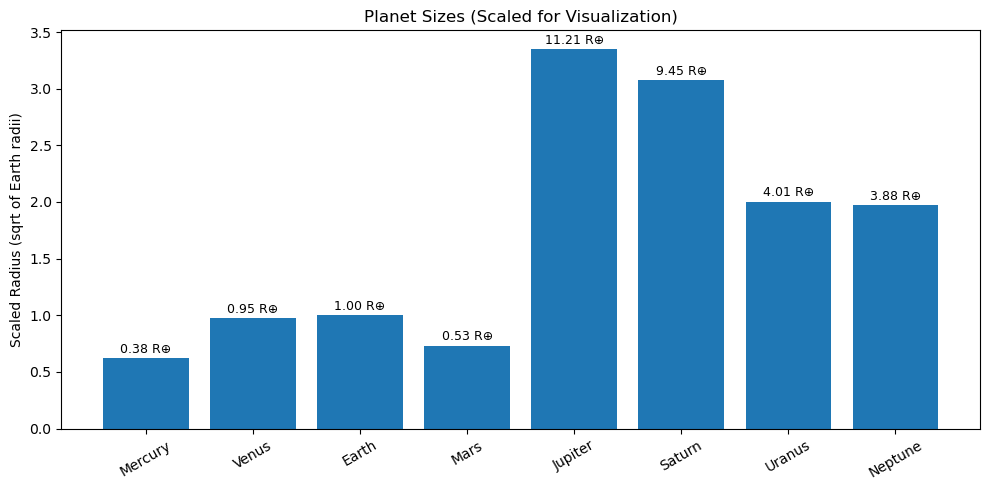

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

# Planet radii in Earth radii (approx)
planets = [
    "Mercury", "Venus", "Earth", "Mars",
    "Jupiter", "Saturn", "Uranus", "Neptune"
]

radii_earth = np.array([
    0.383,   # Mercury
    0.949,   # Venus
    1.0,     # Earth
    0.532,   # Mars
    11.21,   # Jupiter
    9.45,    # Saturn
    4.01,    # Uranus
    3.88     # Neptune
])

# --- Optional: convert to km using astropy units ---
earth_radius_km = (1 * u.R_earth).to(u.km).value
radii_km = radii_earth * earth_radius_km

# --- scaling for visualization (log scale helps a lot) ---
scaled = np.sqrt(radii_earth)  # better visual balance than raw values

plt.figure(figsize=(10, 5))
bars = plt.bar(planets, scaled)

plt.title("Planet Sizes (Scaled for Visualization)")
plt.ylabel("Scaled Radius (sqrt of Earth radii)")
plt.xticks(rotation=30)

# annotate true values
for i, r in enumerate(radii_earth):
    plt.text(i, scaled[i] + 0.05, f"{r:.2f} R⊕", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

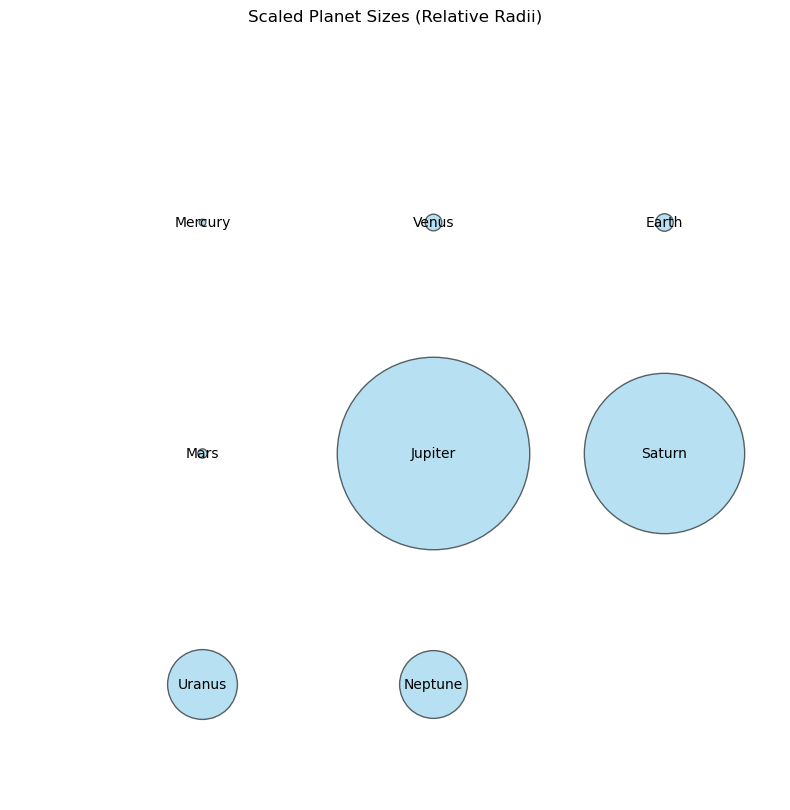

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Planet radii (in km)
planets = {
    "Mercury": 2439.7,
    "Venus": 6051.8,
    "Earth": 6371.0,
    "Mars": 3389.5,
    "Jupiter": 69911,
    "Saturn": 58232,
    "Uranus": 25362,
    "Neptune": 24622
}

# Scale factor so biggest planet fits nicely
max_radius = max(planets.values())
scale = 5.0 / max_radius  # adjust "5.0" to make circles bigger/smaller

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')

# Layout (grid positioning)
cols = 3
x_spacing = 12
y_spacing = 12

for i, (name, radius_km) in enumerate(planets.items()):
    row = i // cols
    col = i % cols

    scaled_radius = radius_km * scale  # now a float, no units

    x = col * x_spacing
    y = -row * y_spacing

    circle = patches.Circle(
        (x, y),
        scaled_radius,
        alpha=0.6,
        edgecolor="black",
        facecolor="skyblue"
    )

    ax.add_patch(circle)
    ax.text(x, y, name, ha="center", va="center", fontsize=10)

ax.set_xlim(-10, 30)
ax.set_ylim(-30, 10)
ax.axis("off")

plt.title("Scaled Planet Sizes (Relative Radii)")
plt.show()